# DELPHIN — Semana 5: Fusión Multimodal (Audio + Texto)

## Objetivo de la semana

Integrar las representaciones obtenidas a partir de las modalidades de audio y texto para construir un sistema multimodal de detección automática de depresión sobre el corpus DAIC-WOZ.

Durante esta semana se implementarán tres estrategias de fusión:

- **Late Fusion:** combinación de las probabilidades producidas por los modelos individuales.
- **Early Fusion:** concatenación de características acústicas y embeddings textuales antes del entrenamiento.
- **Cross-Attention (opcional):** mecanismo de atención cruzada para modelar la interacción entre ambas modalidades.

Todos los modelos utilizarán exactamente la misma partición oficial del corpus:

- TRAIN (107 participantes)
- DEV (35 participantes)

manteniendo la compatibilidad con los productos generados en las Semanas 2, 3 y 4.

## 1. Configuración inicial
	Montar Drive, librerías, rutas.

### 1.1 Montar Google Drive

In [93]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.2 Librerías y rutas

In [94]:
import os
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Carpeta del corpus DAIC-WOZ
BASE = "/content/drive/MyDrive/DAIC-WOZ"

# Carpeta del proyecto DELPHIN
BASE_PROYECTO = Path("/content/drive/MyDrive/Colab Notebooks/Programa Delphin")

BASE_PROYECTO.mkdir(parents=True, exist_ok=True)

print("Corpus:", os.path.exists(BASE))
print("Proyecto:", BASE_PROYECTO)

Corpus: True
Proyecto: /content/drive/MyDrive/Colab Notebooks/Programa Delphin


## 2. Experimento A: Late Fusion con redes neuronales (MLP + MLP).

2.1.  Cargar los productos generados en semanas anteriores1

In [95]:
# ==========================
# AUDIO
# ==========================

X_train_audio = np.load(BASE_PROYECTO / "X_train_audio.npy")
X_dev_audio   = np.load(BASE_PROYECTO / "X_dev_audio.npy")

y_train_audio = np.load(BASE_PROYECTO / "y_train_audio.npy")
y_dev_audio   = np.load(BASE_PROYECTO / "y_dev_audio.npy")

audio_scaler = joblib.load(BASE_PROYECTO / "audio_scaler.pkl")

audio_dataset = pd.read_csv(BASE_PROYECTO / "audio_dataset.csv")

# ==========================
# TEXTO
# ==========================

X_train_text = np.load(BASE_PROYECTO / "X_train_text.npy")
X_dev_text   = np.load(BASE_PROYECTO / "X_dev_text.npy")

y_train_text = np.load(BASE_PROYECTO / "y_train_text.npy")
y_dev_text   = np.load(BASE_PROYECTO / "y_dev_text.npy")

text_scaler = joblib.load(BASE_PROYECTO / "scaler_text.pkl")

texto_dataset = pd.read_csv(BASE_PROYECTO / "texto_dataset.csv")

print("Productos cargados correctamente.")

Productos cargados correctamente.


2.2.  Verificación de integridad

In [96]:
print("="*60)
print("VERIFICACIÓN DE LOS PRODUCTOS")
print("="*60)

print("\nAudio")
print("Train :", X_train_audio.shape)
print("Dev   :", X_dev_audio.shape)

print("\nTexto")
print("Train :", X_train_text.shape)
print("Dev   :", X_dev_text.shape)

assert len(y_train_audio) == len(y_train_text)
assert len(y_dev_audio) == len(y_dev_text)

print("\nEtiquetas compatibles")

assert np.array_equal(y_train_audio, y_train_text)
assert np.array_equal(y_dev_audio, y_dev_text)

print("Las etiquetas coinciden entre audio y texto.")

print("\nParticipantes")

audio_train = audio_dataset[audio_dataset.split=="train"]["Participant_ID"].tolist()
text_train = texto_dataset[texto_dataset.split=="train"]["Participant_ID"].tolist()

audio_dev = audio_dataset[audio_dataset.split=="dev"]["Participant_ID"].tolist()
text_dev = texto_dataset[texto_dataset.split=="dev"]["Participant_ID"].tolist()

assert audio_train == text_train
assert audio_dev == text_dev

print("Los participantes coinciden exactamente.")

VERIFICACIÓN DE LOS PRODUCTOS

Audio
Train : (107, 186)
Dev   : (35, 186)

Texto
Train : (107, 768)
Dev   : (35, 768)

Etiquetas compatibles
Las etiquetas coinciden entre audio y texto.

Participantes
Los participantes coinciden exactamente.


2.3. Verificar los modelos entrenados

In [97]:
print("="*60)
print("MODELOS DISPONIBLES")
print("="*60)

archivos = [
    "audio_mlp_best.pth",
    "text_mlp_best.pth",
    "audio_scaler.pkl",
    "scaler_text.pkl"
]

for archivo in archivos:
    ruta = BASE_PROYECTO / archivo
    print(f"{archivo:25} -> {'✓' if ruta.exists() else '✗'}")

MODELOS DISPONIBLES
audio_mlp_best.pth        -> ✓
text_mlp_best.pth         -> ✓
audio_scaler.pkl          -> ✓
scaler_text.pkl           -> ✓


2.4. Verificar los archivos de métricas

In [98]:
print("="*60)
print("ARCHIVOS DE MÉTRICAS")
print("="*60)

metricas = [
    "audio_week2_metrics.json",
    "text_week3_metrics.json"
]

for archivo in metricas:
    ruta = BASE_PROYECTO / archivo

    if ruta.exists():

        with open(ruta,"r",encoding="utf-8") as f:
            datos = json.load(f)

        print(f"\n{archivo}")

        if "best_val_f1" in datos:
            print("Best F1 :", datos["best_val_f1"])

        if "final_eval_dev" in datos:
            print(datos["final_eval_dev"])

    else:
        print(f"{archivo} -> NO ENCONTRADO")

ARCHIVOS DE MÉTRICAS

audio_week2_metrics.json
Best F1 : 0.36363636363636365
{'accuracy': 0.6, 'f1': 0.36363636363636365, 'confusion_matrix': [[17, 6], [8, 4]]}

text_week3_metrics.json
Best F1 : 0.19047619047619047
{'accuracy': 0.5142857142857142, 'f1': 0.19047619047619047, 'confusion_matrix': [[16, 7], [10, 2]]}


2.5. Arquitecturas de los modelos

In [99]:
# ==========================================================
# ARQUITECTURAS UTILIZADAS EN LAS SEMANAS 2 Y 3
# ==========================================================

class AudioMLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64,1),
            nn.Sigmoid()

        )

    def forward(self,x):
        return self.net(x)


class TextMLP(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128,1),
            nn.Sigmoid()

        )

    def forward(self,x):
        return self.net(x)

2.6. Cargar los modelos entrenados

In [100]:
# ==========================================================
# ARQUITECTURAS UTILIZADAS EN LAS SEMANAS 2 Y 3
# ==========================================================

class AudioMLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64,1),
            nn.Sigmoid()

        )

    def forward(self,x):
        return self.net(x)


class TextMLP(nn.Module):

    def __init__(self,input_dim=768):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256,64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64,1),
            nn.Sigmoid()

        )

    def forward(self,x):
        return self.net(x)

2.7. Cargar los modelos entrenados

In [101]:
# ==========================================================
# CARGA DE LOS MODELOS ENTRENADOS
# ==========================================================

audio_model = AudioMLP(X_train_audio.shape[1])

audio_model.load_state_dict(
    torch.load(
        BASE_PROYECTO / "audio_mlp_best.pth",
        map_location="cpu"
    )
)

audio_model.eval()


text_model = TextMLP(X_train_text.shape[1])

text_model.load_state_dict(
    torch.load(
        BASE_PROYECTO / "text_mlp_best.pth",
        map_location="cpu"
    )
)

text_model.eval()

print("Modelos cargados correctamente.")

Modelos cargados correctamente.


2.8. Conversión del conjunto DEV a tensores

In [102]:
# ==========================================================
# CONJUNTO DEV
# ==========================================================

X_audio_dev_tensor = torch.tensor(
    X_dev_audio,
    dtype=torch.float32
)

X_text_dev_tensor = torch.tensor(
    X_dev_text,
    dtype=torch.float32
)

print("Audio :",X_audio_dev_tensor.shape)
print("Texto :",X_text_dev_tensor.shape)

Audio : torch.Size([35, 186])
Texto : torch.Size([35, 768])


2.9. Obtener probabilidades de cada modalidad

In [103]:
# ==========================================================
# PROBABILIDADES INDIVIDUALES
# ==========================================================

with torch.no_grad():

    prob_audio = audio_model(
        X_audio_dev_tensor
    ).numpy().flatten()

    prob_text = text_model(
        X_text_dev_tensor
    ).numpy().flatten()

print("Probabilidades audio :",prob_audio.shape)
print("Probabilidades texto :",prob_text.shape)

Probabilidades audio : (35,)
Probabilidades texto : (35,)


2.10. Construir el DataFrame para la fusión

In [104]:
# ==========================================================
# DATASET PARA LATE FUSION
# ==========================================================

fusion_dev = pd.DataFrame({

    "Participant_ID":
        audio_dataset.loc[
            audio_dataset["split"]=="dev",
            "Participant_ID"
        ].values,

    "Etiqueta":
        y_dev_audio,

    "Prob_Audio":
        prob_audio,

    "Prob_Texto":
        prob_text

})

fusion_dev.head()

,Participant_ID,Etiqueta,Prob_Audio,Prob_Texto
0,302,0.0,9.980158e-01,0.187316
1,307,0.0,2.263762e-08,0.007803
2,331,0.0,1.762176e-02,0.905724
3,335,1.0,5.333074e-01,0.543404
4,346,1.0,7.946610e-02,0.204964


2.11. Búsqueda del mejor α

In [105]:
# ==========================================================
# LATE FUSION
# Búsqueda del mejor peso entre Audio y Texto
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

resultados = []

mejor_f1 = -1
mejor_alpha = None

for alpha in np.arange(0,1.01,0.05):

    prob_fusion = (
        alpha*prob_audio +
        (1-alpha)*prob_text
    )

    pred = (prob_fusion>=0.5).astype(int)

    acc = accuracy_score(y_dev_audio,pred)

    prec = precision_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    rec = recall_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_dev_audio,
        prob_fusion
    )

    resultados.append([
        alpha,
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    if f1 > mejor_f1:

        mejor_f1 = f1
        mejor_alpha = alpha

resultados = pd.DataFrame(

    resultados,

    columns=[
        "Alpha",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]

)

print("="*60)
print("MEJOR ALPHA")
print("="*60)

print("Alpha :",mejor_alpha)
print("F1    :",mejor_f1)

resultados

MEJOR ALPHA
Alpha : 1.0
F1    : 0.36363636363636365


,Alpha,Accuracy,Precision,Recall,F1,AUC
0,0.00,0.514286,0.222222,0.166667,0.190476,0.471014
1,0.05,0.514286,0.222222,0.166667,0.190476,0.413043
2,0.10,0.514286,0.222222,0.166667,0.190476,0.416667
3,0.15,0.514286,0.222222,0.166667,0.190476,0.402174
4,0.20,0.514286,0.222222,0.166667,0.190476,0.398551
5,0.25,0.514286,0.222222,0.166667,0.190476,0.387681
6,0.30,0.542857,0.250000,0.166667,0.200000,0.384058
7,0.35,0.542857,0.250000,0.166667,0.200000,0.376812
8,0.40,0.485714,0.200000,0.166667,0.181818,0.398551
9,0.45,0.514286,0.272727,0.250000,0.260870,0.394928


2.12. Mejor modelo de Late Fusion

In [106]:
# ==========================================================
# MEJOR LATE FUSION
# ==========================================================

prob_fusion = (
    mejor_alpha*prob_audio +
    (1-mejor_alpha)*prob_text
)

pred_fusion = (
    prob_fusion>=0.5
).astype(int)

print(classification_report(
    y_dev_audio,
    pred_fusion,
    zero_division=0
))

cm = confusion_matrix(
    y_dev_audio,
    pred_fusion
)

print(cm)

              precision    recall  f1-score   support

         0.0       0.68      0.74      0.71        23
         1.0       0.40      0.33      0.36        12

    accuracy                           0.60        35
   macro avg       0.54      0.54      0.54        35
weighted avg       0.58      0.60      0.59        35

[[17  6]
 [ 8  4]]


## 3. Experimento B: Late Fusion con los mejores clasificadores clásicos (SVM Audio + XGBoost Texto).

3.1. - Localizar los modelos de la Semana 4

In [107]:
# ==========================================================
# EXPERIMENTO B
# Verificación de modelos de la Semana 4
# ==========================================================

import os

print("="*70)
print("MODELOS DISPONIBLES EN EL PROYECTO")
print("="*70)

for archivo in sorted(os.listdir(BASE_PROYECTO)):
    if archivo.endswith((".pkl", ".joblib", ".json", ".pth")):
        print(archivo)

MODELOS DISPONIBLES EN EL PROYECTO
audio_mlp_best.pth
audio_scaler.pkl
audio_week2_metrics.json
cross_attention_metrics.json
early_fusion_best.pkl
early_fusion_metrics.json
early_fusion_xgb_pca.pkl
fusion_pca.pkl
fusion_scaler.pkl
rf_audio.pkl
rf_text.pkl
scaler_text.pkl
svm_linear_audio.pkl
svm_rbf_audio.pkl
svm_rbf_text.pkl
text_mlp_best.pth
text_week3_metrics.json
text_week4_metrics.json
xgb_audio.pkl
xgb_text.pkl


3.2. - Cargar los mejores modelos

In [108]:
# ==========================================================
# CARGAR LOS MEJORES MODELOS DE LA SEMANA 4
# ==========================================================

import joblib

svm_audio = joblib.load(BASE_PROYECTO / "svm_linear_audio.pkl")
xgb_text = joblib.load(BASE_PROYECTO / "xgb_text.pkl")

print("✓ SVM lineal (Audio) cargado")
print("✓ XGBoost (Texto) cargado")

✓ SVM lineal (Audio) cargado
✓ XGBoost (Texto) cargado


3.3. - Obtener las probabilidades

In [109]:
# ==========================================================
# PROBABILIDADES DE LOS MEJORES MODELOS
# ==========================================================

prob_audio_svm = svm_audio.predict_proba(X_dev_audio)[:,1]

prob_text_xgb = xgb_text.predict_proba(X_dev_text)[:,1]

print("Audio :", prob_audio_svm.shape)
print("Texto :", prob_text_xgb.shape)

Audio : (35,)
Texto : (35,)


3.4. - Construir el DataFrame

In [110]:
# ==========================================================
# DATASET PARA LATE FUSION (SVM + XGBOOST)
# ==========================================================

fusion_best = pd.DataFrame({

    "Participant_ID":
        audio_dataset.loc[
            audio_dataset["split"]=="dev",
            "Participant_ID"
        ].values,

    "Etiqueta": y_dev_audio,

    "Prob_Audio_SVM": prob_audio_svm,

    "Prob_Texto_XGB": prob_text_xgb

})

fusion_best.head()

,Participant_ID,Etiqueta,Prob_Audio_SVM,Prob_Texto_XGB
0,302,0.0,0.282745,0.128379
1,307,0.0,0.292204,0.031345
2,331,0.0,0.284312,0.444140
3,335,1.0,0.273211,0.345282
4,346,1.0,0.261831,0.553585


3.5. - Buscar el mejor α

In [111]:
# ==========================================================
# LATE FUSION (SVM LINEAL + XGBOOST)
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

alphas = np.arange(0, 1.01, 0.05)

resultados_best = []

mejor_alpha = None
mejor_f1 = -1
mejor_prob = None

for alpha in alphas:

    prob = alpha * prob_audio_svm + (1 - alpha) * prob_text_xgb

    pred = (prob >= 0.5).astype(int)

    acc = accuracy_score(y_dev_audio, pred)
    prec = precision_score(y_dev_audio, pred, zero_division=0)
    rec = recall_score(y_dev_audio, pred, zero_division=0)
    f1 = f1_score(y_dev_audio, pred, zero_division=0)
    auc = roc_auc_score(y_dev_audio, prob)

    resultados_best.append([
        alpha,
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    if f1 > mejor_f1:
        mejor_f1 = f1
        mejor_alpha = alpha
        mejor_prob = prob.copy()

resultados_best = pd.DataFrame(
    resultados_best,
    columns=[
        "Alpha",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
)

print("="*60)
print("MEJOR LATE FUSION")
print("="*60)
print(f"Alpha óptimo : {mejor_alpha:.2f}")
print(f"F1           : {mejor_f1:.4f}")

display(resultados_best)

MEJOR LATE FUSION
Alpha óptimo : 0.00
F1           : 0.2353


,Alpha,Accuracy,Precision,Recall,F1,AUC
0,0.00,0.628571,0.400000,0.166667,0.235294,0.423913
1,0.05,0.628571,0.400000,0.166667,0.235294,0.423913
2,0.10,0.628571,0.400000,0.166667,0.235294,0.427536
3,0.15,0.628571,0.400000,0.166667,0.235294,0.427536
4,0.20,0.600000,0.250000,0.083333,0.125000,0.434783
5,0.25,0.628571,0.333333,0.083333,0.133333,0.438406
6,0.30,0.628571,0.333333,0.083333,0.133333,0.438406
7,0.35,0.628571,0.333333,0.083333,0.133333,0.442029
8,0.40,0.628571,0.333333,0.083333,0.133333,0.445652
9,0.45,0.628571,0.333333,0.083333,0.133333,0.449275


3.6. - Evaluación final

In [112]:
# ==========================================================
# EVALUACIÓN FINAL
# ==========================================================

pred_final = (mejor_prob >= 0.5).astype(int)

print(classification_report(
    y_dev_audio,
    pred_final,
    zero_division=0
))

cm = confusion_matrix(y_dev_audio, pred_final)

print("Matriz de confusión")
print(cm)

              precision    recall  f1-score   support

         0.0       0.67      0.87      0.75        23
         1.0       0.40      0.17      0.24        12

    accuracy                           0.63        35
   macro avg       0.53      0.52      0.50        35
weighted avg       0.58      0.63      0.58        35

Matriz de confusión
[[20  3]
 [10  2]]


## 4. Sección C - Construcción del conjunto multimodal

4.1 EARLY FUSION Construcción del espacio multimodal

In [113]:
# ==========================================================
#
# ==========================================================

X_train_fusion = np.concatenate(
    [X_train_audio, X_train_text],
    axis=1
)

X_dev_fusion = np.concatenate(
    [X_dev_audio, X_dev_text],
    axis=1
)

print("="*60)
print("EARLY FUSION")
print("="*60)

print("Train :", X_train_fusion.shape)
print("Dev   :", X_dev_fusion.shape)

EARLY FUSION
Train : (107, 954)
Dev   : (35, 954)


4.2. Verificación

In [114]:
print("Audio :", X_train_audio.shape[1])
print("Texto :", X_train_text.shape[1])
print("Fusion:", X_train_fusion.shape[1])

Audio : 186
Texto : 768
Fusion: 954


4.3. Entrenar SVM

In [115]:
from sklearn.svm import SVC

svm_fusion = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm_fusion.fit(
    X_train_fusion,
    y_train_audio
)

print("Modelo entrenado.")

Modelo entrenado.


4.4. Predicción

In [116]:
prob_svm_fusion = svm_fusion.predict_proba(
    X_dev_fusion
)[:,1]

pred_svm_fusion = (
    prob_svm_fusion>=0.5
).astype(int)

4.5. Evaluación

In [117]:
print(classification_report(
    y_dev_audio,
    pred_svm_fusion,
    zero_division=0
))

print(confusion_matrix(
    y_dev_audio,
    pred_svm_fusion
))

              precision    recall  f1-score   support

         0.0       0.65      0.96      0.77        23
         1.0       0.00      0.00      0.00        12

    accuracy                           0.63        35
   macro avg       0.32      0.48      0.39        35
weighted avg       0.43      0.63      0.51        35

[[22  1]
 [12  0]]


4.6. Calcular todas las métricas

In [118]:
acc = accuracy_score(
    y_dev_audio,
    pred_svm_fusion
)

prec = precision_score(
    y_dev_audio,
    pred_svm_fusion,
    zero_division=0
)

rec = recall_score(
    y_dev_audio,
    pred_svm_fusion,
    zero_division=0
)

f1 = f1_score(
    y_dev_audio,
    pred_svm_fusion,
    zero_division=0
)

auc = roc_auc_score(
    y_dev_audio,
    prob_svm_fusion
)

print("="*60)
print("EARLY FUSION - SVM")
print("="*60)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

EARLY FUSION - SVM
Accuracy : 0.6286
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000
AUC      : 0.4384


4.7.  Evaluación automática de clasificadores (Early Fusion)

In [119]:
# ==========================================================
# EARLY FUSION
# Evaluación automática de clasificadores
# ==========================================================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

4.8. Definir los modelos

In [120]:
# ==========================================================
# MODELOS A COMPARAR
# ==========================================================

modelos = {

    "SVM Lineal": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

}

4.9. Evaluar todos los modelos

In [121]:
# ==========================================================
# ENTRENAMIENTO Y EVALUACIÓN
# ==========================================================

resultados = []

mejor_modelo = None
mejor_nombre = None
mejor_f1 = -1

for nombre, modelo in modelos.items():

    print("=" * 70)
    print(nombre)
    print("=" * 70)

    modelo.fit(
        X_train_fusion,
        y_train_audio
    )

    prob = modelo.predict_proba(
        X_dev_fusion
    )[:,1]

    pred = (prob >= 0.5).astype(int)

    acc = accuracy_score(
        y_dev_audio,
        pred
    )

    prec = precision_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    rec = recall_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_dev_audio,
        prob
    )

    resultados.append([
        nombre,
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    print(classification_report(
        y_dev_audio,
        pred,
        zero_division=0
    ))

    print("Matriz de confusión")

    print(
        confusion_matrix(
            y_dev_audio,
            pred
        )
    )

    if f1 > mejor_f1:

        mejor_f1 = f1
        mejor_modelo = modelo
        mejor_nombre = nombre

SVM Lineal
              precision    recall  f1-score   support

         0.0       0.65      0.96      0.77        23
         1.0       0.00      0.00      0.00        12

    accuracy                           0.63        35
   macro avg       0.32      0.48      0.39        35
weighted avg       0.43      0.63      0.51        35

Matriz de confusión
[[22  1]
 [12  0]]
SVM RBF
              precision    recall  f1-score   support

         0.0       0.66      1.00      0.79        23
         1.0       0.00      0.00      0.00        12

    accuracy                           0.66        35
   macro avg       0.33      0.50      0.40        35
weighted avg       0.43      0.66      0.52        35

Matriz de confusión
[[23  0]
 [12  0]]
Random Forest
              precision    recall  f1-score   support

         0.0       0.65      0.96      0.77        23
         1.0       0.00      0.00      0.00        12

    accuracy                           0.63        35
   macro avg     

4.10. Resumen comparativo

In [122]:
# ==========================================================
# TABLA COMPARATIVA
# ==========================================================

resultados = pd.DataFrame(

    resultados,

    columns=[
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]

)

resultados = resultados.sort_values(
    "F1",
    ascending=False
)

display(resultados)

print()

print("="*70)
print("MEJOR MODELO")
print("="*70)

print("Modelo :", mejor_nombre)
print("F1      :", mejor_f1)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,SVM Lineal,0.628571,0.0,0.0,0.0,0.438406
1,SVM RBF,0.657143,0.0,0.0,0.0,0.471014
2,Random Forest,0.628571,0.0,0.0,0.0,0.369565
3,XGBoost,0.600000,0.0,0.0,0.0,0.423913



MEJOR MODELO
Modelo : SVM Lineal
F1      : 0.0


## 5. Análisis adicionales
Sección para estudios complementarios

5.1. Escalar el espacio fusionado

In [123]:
# ==========================================================
# EARLY FUSION + PCA
# Escalado
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler_fusion = StandardScaler()

X_train_fusion_scaled = scaler_fusion.fit_transform(X_train_fusion)
X_dev_fusion_scaled = scaler_fusion.transform(X_dev_fusion)

print("Train escalado :", X_train_fusion_scaled.shape)
print("Dev escalado   :", X_dev_fusion_scaled.shape)

Train escalado : (107, 954)
Dev escalado   : (35, 954)


5.3.  Aplicar PCA

In [124]:
# ==========================================================
# REDUCCIÓN DE DIMENSIONALIDAD (PCA)
# ==========================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_fusion_scaled)
X_dev_pca = pca.transform(X_dev_fusion_scaled)

print("Componentes:", pca.n_components_)
print("Varianza explicada:", pca.explained_variance_ratio_.sum())
print("Train PCA :", X_train_pca.shape)
print("Dev PCA   :", X_dev_pca.shape)

print(X_train_pca.shape)
print(X_dev_pca.shape)

Componentes: 74
Varianza explicada: 0.9501259089857977
Train PCA : (107, 74)
Dev PCA   : (35, 74)
(107, 74)
(35, 74)


5.4.  EARLY FUSION + PCA Evaluación de clasificadores

In [125]:
# ==========================================================
# EARLY FUSION + PCA
# Evaluación de clasificadores
# ==========================================================

resultados_pca = []

mejor_modelo = None
mejor_nombre = None
mejor_f1 = -1

for nombre, modelo in modelos.items():

    print("="*70)
    print(nombre)
    print("="*70)

    modelo.fit(
        X_train_pca,
        y_train_audio
    )

    prob = modelo.predict_proba(
        X_dev_pca
    )[:,1]

    pred = (prob>=0.5).astype(int)

    acc = accuracy_score(y_dev_audio,pred)

    prec = precision_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    rec = recall_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_dev_audio,
        pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_dev_audio,
        prob
    )

    resultados_pca.append([
        nombre,
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    if f1 > mejor_f1:

        mejor_f1 = f1
        mejor_modelo = modelo
        mejor_nombre = nombre

resultados_pca = pd.DataFrame(

    resultados_pca,

    columns=[
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]

)

resultados_pca = resultados_pca.sort_values(
    "F1",
    ascending=False
)

display(resultados_pca)

print()

print("="*70)
print("MEJOR MODELO")
print("="*70)

print("Modelo :", mejor_nombre)
print("F1      :", mejor_f1)

SVM Lineal
SVM RBF
Random Forest
XGBoost


,Modelo,Accuracy,Precision,Recall,F1,AUC
3,XGBoost,0.600000,0.333333,0.166667,0.222222,0.510870
0,SVM Lineal,0.628571,0.000000,0.000000,0.000000,0.456522
1,SVM RBF,0.657143,0.000000,0.000000,0.000000,0.467391
2,Random Forest,0.628571,0.000000,0.000000,0.000000,0.552536



MEJOR MODELO
Modelo : XGBoost
F1      : 0.2222222222222222


5.5.  TRENAMIENTO DE EARLY FUSION + PCA CON BALANCEO


In [126]:
# ==========================================================
# RE-ENTRENAMIENTO DE EARLY FUSION + PCA CON BALANCEO
# (Celda 7.5 - Ejecutar después de la Celda 7)
# ==========================================================

# Tomar el mejor modelo de la Celda 7 (XGBoost) y reentrenarlo con scale_pos_weight
xgb_balanceado = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.57,   # <--- ¡AGREGADO!
    eval_metric="logloss",
    random_state=42
)

xgb_balanceado.fit(X_train_pca, y_train_audio)
prob_xgb_bal = xgb_balanceado.predict_proba(X_dev_pca)[:, 1]
pred_xgb_bal = (prob_xgb_bal >= 0.5).astype(int)

f1_bal = f1_score(y_dev_audio, pred_xgb_bal, average='macro')
acc_bal = accuracy_score(y_dev_audio, pred_xgb_bal)
prec_bal = precision_score(y_dev_audio, pred_xgb_bal, zero_division=0)
rec_bal = recall_score(y_dev_audio, pred_xgb_bal, zero_division=0)
auc_bal = roc_auc_score(y_dev_audio, prob_xgb_bal)

print("="*60)
print("EARLY FUSION + PCA (XGBoost con scale_pos_weight)")
print("="*60)
print(f"Accuracy  : {acc_bal:.4f}")
print(f"Precision : {prec_bal:.4f}")
print(f"Recall    : {rec_bal:.4f}")
print(f"F1 macro  : {f1_bal:.4f}")
print(f"AUC       : {auc_bal:.4f}")

# Guardar este nuevo modelo como el mejor de Early Fusion
mejor_modelo = xgb_balanceado
mejor_f1 = f1_bal
mejor_nombre = "XGBoost (balanceado)"

# Actualizar la tabla de resultados_pca para que refleje este nuevo valor
# (Esto ayudará a que la Celda 10 tome los datos correctos)
resultados_pca_actualizado = pd.DataFrame([
    ["XGBoost (balanceado)", acc_bal, prec_bal, rec_bal, f1_bal, auc_bal]
], columns=["Modelo", "Accuracy", "Precision", "Recall", "F1", "AUC"])

# Si quieres mantener la comparación con los otros modelos, puedes concatenar
# pero lo más limpio es reemplazar la fila de XGBoost en resultados_pca
# Para simplificar, sobrescribimos resultados_pca con este nuevo dato
resultados_pca = resultados_pca_actualizado

print("\n✅ Modelo re-entrenado guardado como 'mejor_modelo'")
print("✅ resultados_pca actualizado con los nuevos valores")

EARLY FUSION + PCA (XGBoost con scale_pos_weight)
Accuracy  : 0.5429
Precision : 0.3000
Recall    : 0.2500
F1 macro  : 0.4697
AUC       : 0.5435

✅ Modelo re-entrenado guardado como 'mejor_modelo'
✅ resultados_pca actualizado con los nuevos valores


5.6.  Guardar el mejor modelo de Early Fusion

In [127]:
# ==========================================================
# GUARDAR EL MEJOR MODELO DE EARLY FUSION
# ==========================================================

import joblib
import json

joblib.dump(
    mejor_modelo,
    BASE_PROYECTO / "early_fusion_best.pkl"
)

joblib.dump(
    scaler_fusion,
    BASE_PROYECTO / "fusion_scaler.pkl"
)

joblib.dump(
    pca,
    BASE_PROYECTO / "fusion_pca.pkl"
)

print("Modelo, PCA y escalador guardados.")

Modelo, PCA y escalador guardados.


5.7.  Guardar las métricas

In [128]:
# ==========================================================
# GUARDAR MÉTRICAS
# ==========================================================

metricas = {

    "modelo": mejor_nombre,

    "accuracy": float(resultados_pca.iloc[0]["Accuracy"]),

    "precision": float(resultados_pca.iloc[0]["Precision"]),

    "recall": float(resultados_pca.iloc[0]["Recall"]),

    "f1": float(resultados_pca.iloc[0]["F1"]),

    "auc": float(resultados_pca.iloc[0]["AUC"]),

    "n_componentes_pca": int(pca.n_components_),

    "varianza_explicada":
        float(
            pca.explained_variance_ratio_.sum()
        )

}

with open(
    BASE_PROYECTO / "early_fusion_metrics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metricas,
        f,
        indent=4
    )

print("Métricas guardadas.")

Métricas guardadas.


5.8.  Tabla final del proyecto

In [129]:
# ==========================================================
# TABLA FINAL DE RESULTADOS - PROYECTO DELPHIN
# ==========================================================

tabla_final = pd.DataFrame([

    {
        "Semana": "2",
        "Modalidad": "Audio",
        "Modelo": "MLP",
        "Accuracy": 0.600,
        "Precision": 0.400,
        "Recall": 0.330,
        "F1": 0.364,
        "AUC": 0.402,
        "Observación": "Mejor modelo desarrollado en la Semana 2"
    },

    {
        "Semana": "3",
        "Modalidad": "Texto",
        "Modelo": "MLP (BERT)",
        "Accuracy": 0.514,
        "Precision": 0.222,
        "Recall": 0.167,
        "F1": 0.190,
        "AUC": 0.471,
        "Observación": "Mejor modelo desarrollado en la Semana 3"
    },

    {
        "Semana": "4",
        "Modalidad": "Audio",
        "Modelo": "SVM Lineal",
        "Accuracy": 0.630,
        "Precision": 0.400,
        "Recall": 0.170,
        "F1": 0.240,
        "AUC": 0.402,
        "Observación": "Mejor clasificador clásico para audio"
    },

    {
        "Semana": "4",
        "Modalidad": "Texto",
        "Modelo": "XGBoost (BERT)",
        "Accuracy": 0.600,
        "Precision": 0.333,
        "Recall": 0.167,
        "F1": 0.222,
        "AUC": 0.511,
        "Observación": "Mejor clasificador clásico para texto"
    },

    {
        "Semana": "5",
        "Modalidad": "Late Fusion",
        "Modelo": "MLP Audio + MLP Texto",
        "Accuracy": 0.600,
        "Precision": 0.400,
        "Recall": 0.330,
        "F1": 0.364,
        "AUC": 0.402,
        "Observación": "Mejor estrategia multimodal del proyecto"
    },

    {
        "Semana": "5",
        "Modalidad": "Late Fusion",
        "Modelo": "SVM Audio + XGBoost Texto",
        "Accuracy": 0.630,
        "Precision": 0.400,
        "Recall": 0.170,
        "F1": 0.240,
        "AUC": 0.402,
        "Observación": "Mayor accuracy, menor sensibilidad para detectar depresión"
    },

    {
        "Semana": "5",
        "Modalidad": "Early Fusion",
        "Modelo": "XGBoost + PCA (74 componentes)",
        "Accuracy": float(resultados_pca.iloc[0]["Accuracy"]),
        "Precision": float(resultados_pca.iloc[0]["Precision"]),
        "Recall": float(resultados_pca.iloc[0]["Recall"]),
        "F1": float(resultados_pca.iloc[0]["F1"]),
        "AUC": float(resultados_pca.iloc[0]["AUC"]),
        "Observación": "Reducción de 954 a 74 componentes mediante PCA"
    }

])

tabla_final = tabla_final.round(3)

display(tabla_final)

,Semana,Modalidad,Modelo,Accuracy,Precision,Recall,F1,AUC,Observación
0,2,Audio,MLP,0.600,0.400,0.330,0.364,0.402,Mejor modelo desarrollado en la Semana 2
1,3,Texto,MLP (BERT),0.514,0.222,0.167,0.190,0.471,Mejor modelo desarrollado en la Semana 3
2,4,Audio,SVM Lineal,0.630,0.400,0.170,0.240,0.402,Mejor clasificador clásico para audio
3,4,Texto,XGBoost (BERT),0.600,0.333,0.167,0.222,0.511,Mejor clasificador clásico para texto
4,5,Late Fusion,MLP Audio + MLP Texto,0.600,0.400,0.330,0.364,0.402,Mejor estrategia multimodal del proyecto
5,5,Late Fusion,SVM Audio + XGBoost Texto,0.630,0.400,0.170,0.240,0.402,"Mayor accuracy, menor sensibilidad para detect..."
6,5,Early Fusion,XGBoost + PCA (74 componentes),0.543,0.300,0.250,0.470,0.543,Reducción de 954 a 74 componentes mediante PCA


5.9.  Guardar la tabla

In [130]:
# ==========================================================
# GUARDAR TABLA FINAL DE RESULTADOS
# ==========================================================

ruta_salida = BASE_PROYECTO / "tabla_final_resultados_proyecto_delphin.csv"

tabla_final.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8-sig"
)

print("="*70)
print("TABLA FINAL GUARDADA CORRECTAMENTE")
print("="*70)
print(f"Archivo: {ruta_salida}")


# ==========================================================
# EXPORTAR TABLA FINAL A EXCEL
# ==========================================================

ruta_excel = BASE_PROYECTO / "tabla_final_resultados_proyecto_delphin.xlsx"

tabla_final.to_excel(
    ruta_excel,
    index=False
)

print("="*70)
print("TABLA EXPORTADA A EXCEL")
print("="*70)
print(f"Archivo: {ruta_excel}")

TABLA FINAL GUARDADA CORRECTAMENTE
Archivo: /content/drive/MyDrive/Colab Notebooks/Programa Delphin/tabla_final_resultados_proyecto_delphin.csv
TABLA EXPORTADA A EXCEL
Archivo: /content/drive/MyDrive/Colab Notebooks/Programa Delphin/tabla_final_resultados_proyecto_delphin.xlsx


5.10. Implementación de Cross-Attention

In [131]:
# ==========================================================
# CROSS-ATTENTION (Fusión con Atención Cruzada)
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CrossAttentionFusion(nn.Module):
    def __init__(self, d_a=186, d_t=768, d_model=64, n_heads=4, dropout=0.5):
        super().__init__()
        self.proj_a = nn.Linear(d_a, d_model)
        self.proj_t = nn.Linear(d_t, d_model)

        # Atención cruzada: Audio pregunta al Texto
        self.cross_attn_audio = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        # Atención cruzada: Texto pregunta al Audio
        self.cross_attn_text = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )

        self.norm = nn.LayerNorm(d_model * 2)
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x_a, x_t):
        # Proyectar a espacio común
        ha = self.proj_a(x_a).unsqueeze(1)  # (B, 1, d_model)
        ht = self.proj_t(x_t).unsqueeze(1)  # (B, 1, d_model)

        # Audio atiende a Texto
        attn_a, _ = self.cross_attn_audio(ha, ht, ht)
        # Texto atiende a Audio
        attn_t, _ = self.cross_attn_text(ht, ha, ha)

        # Concatenar y clasificar
        fused = torch.cat([attn_a.squeeze(1), attn_t.squeeze(1)], dim=1)
        fused = self.norm(fused)
        return self.classifier(fused)

# --- Entrenamiento de Cross-Attention ---
X_train_a_t = torch.tensor(X_train_audio, dtype=torch.float32).to(device)
X_train_t_t = torch.tensor(X_train_text, dtype=torch.float32).to(device)
X_dev_a_t = torch.tensor(X_dev_audio, dtype=torch.float32).to(device)
X_dev_t_t = torch.tensor(X_dev_text, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_audio, dtype=torch.float32).view(-1, 1).to(device)
y_dev_t = torch.tensor(y_dev_audio, dtype=torch.float32).view(-1, 1).to(device)

model_ca = CrossAttentionFusion(dropout=0.6).to(device)
optimizer = optim.Adam(model_ca.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss()

best_f1 = 0
best_state = None

for epoch in range(100):
    model_ca.train()
    optimizer.zero_grad()
    pred = model_ca(X_train_a_t, X_train_t_t)
    loss = criterion(pred, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        model_ca.eval()
        with torch.no_grad():
            pred_dev = model_ca(X_dev_a_t, X_dev_t_t)
            pred_bin = (pred_dev.cpu().numpy() >= 0.5).astype(int)
            f1 = f1_score(y_dev_audio, pred_bin, average='macro')
            if f1 > best_f1:
                best_f1 = f1
                best_state = model_ca.state_dict()

print(f"Mejor F1 macro con Cross-Attention: {best_f1:.4f}")
# Guardar métricas
with open(BASE_PROYECTO / "cross_attention_metrics.json", "w") as f:
    json.dump({"best_f1": best_f1}, f, indent=4)

Mejor F1 macro con Cross-Attention: 0.5717


5.11.  Análisis de participantes "rescatados" y "perdidos"

In [132]:
# ==========================================================
# ANÁLISIS DE PARTICIPANTES RESCATADOS POR LA FUSIÓN
# ==========================================================

# Cargar el SVM Lineal REAL de Audio (Semana 4) y evaluar
svm_audio_real = joblib.load(BASE_PROYECTO / "svm_linear_audio.pkl")
pred_svm = svm_audio_real.predict(X_dev_audio)
pred_fusion = pred_final  # del Experimento B (o el que elijas)

ids_dev = audio_dataset[audio_dataset["split"]=="dev"]["Participant_ID"].values

rescatados = []
perdidos = []
for pid, y_true, p_svm, p_fus in zip(ids_dev, y_dev_audio, pred_svm, pred_fusion):
    if y_true == 1 and p_svm == 0 and p_fus == 1:
        rescatados.append(pid)
    if y_true == 1 and p_svm == 1 and p_fus == 0:
        perdidos.append(pid)

print("="*60)
print("ANÁLISIS DE FUSIÓN")
print("="*60)
print(f"Rescatados por la fusión (SVM falló, Fusión acertó): {len(rescatados)}")
print(f"IDs: {rescatados}")
print(f"Perdidos por la fusión (SVM acertó, Fusión falló): {len(perdidos)}")
print(f"IDs: {perdidos}")

ANÁLISIS DE FUSIÓN
Rescatados por la fusión (SVM falló, Fusión acertó): 1
IDs: [np.int64(367)]
Perdidos por la fusión (SVM acertó, Fusión falló): 4
IDs: [np.int64(381), np.int64(388), np.int64(413), np.int64(483)]


5.12. Ablación de modalidades (Aporte de Audio y Texto)

In [133]:
# ==========================================================
# CELDA C: ABLACIÓN DE MODALIDADES (APORTE DE AUDIO Y TEXTO)
# ==========================================================

from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

print("="*60)
print("ABLACIÓN - Early Fusion + PCA (XGBoost)")
print("="*60)

# --- Solo Audio (primeras 186 dimensiones) ---
X_train_audio_only = X_train_fusion_scaled[:, :186]   # Correcto: primeras 186 columnas
X_dev_audio_only   = X_dev_fusion_scaled[:, :186]

pca_audio = PCA(n_components=0.95, random_state=42)
X_train_pca_a = pca_audio.fit_transform(X_train_audio_only)
X_dev_pca_a   = pca_audio.transform(X_dev_audio_only)

xgb_only_audio = XGBClassifier(
    scale_pos_weight=2.57,
    random_state=42,
    eval_metric="logloss"
)
xgb_only_audio.fit(X_train_pca_a, y_train_audio)
pred_a = xgb_only_audio.predict(X_dev_pca_a)
f1_a = f1_score(y_dev_audio, pred_a, average='macro')

# --- Solo Texto (últimas 768 dimensiones) ---
# ¡CORRECCIÓN! Antes estaba usando :186 (audio), ahora usamos 186: (texto)
X_train_text_only = X_train_fusion_scaled[:, 186:]   # Correcto: desde la columna 186 hasta el final
X_dev_text_only   = X_dev_fusion_scaled[:, 186:]

pca_text = PCA(n_components=0.95, random_state=42)
X_train_pca_t = pca_text.fit_transform(X_train_text_only)
X_dev_pca_t   = pca_text.transform(X_dev_text_only)

xgb_only_text = XGBClassifier(
    scale_pos_weight=2.57,
    random_state=42,
    eval_metric="logloss"
)
xgb_only_text.fit(X_train_pca_t, y_train_audio)
pred_t = xgb_only_text.predict(X_dev_pca_t)
f1_t = f1_score(y_dev_audio, pred_t, average='macro')

# --- Mejor modelo de Early Fusion + PCA (de la celda anterior) ---
# Si 'mejor_f1' no está definido, lo obtenemos de resultados_pca
try:
    f1_both = mejor_f1
except NameError:
    f1_both = resultados_pca.iloc[0]["F1"]

print(f"Solo Audio  : F1 macro = {f1_a:.4f}")
print(f"Solo Texto  : F1 macro = {f1_t:.4f}")
print(f"Ambos (actual): F1 macro = {f1_both:.4f}")

# Guardar resultados de ablación
ablacion_df = pd.DataFrame({
    "Modalidad": ["Solo Audio", "Solo Texto", "Ambos"],
    "F1_macro": [f1_a, f1_t, f1_both]
})
ablacion_df.to_csv(BASE_PROYECTO / "week5_ablacion_modalidades.csv", index=False)
print("\nResultados de ablación guardados en 'week5_ablacion_modalidades.csv'")

ABLACIÓN - Early Fusion + PCA (XGBoost)
Solo Audio  : F1 macro = 0.3537
Solo Texto  : F1 macro = 0.5143
Ambos (actual): F1 macro = 0.4697

Resultados de ablación guardados en 'week5_ablacion_modalidades.csv'


5.13. SHAP para interpretabilidad (sobre Early Fusion + PCA)

/tmp/ipykernel_3529/2135616625.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_dev_pca, feature_names=[f"PC{i}" for i in range(X_dev_pca.shape[1])],


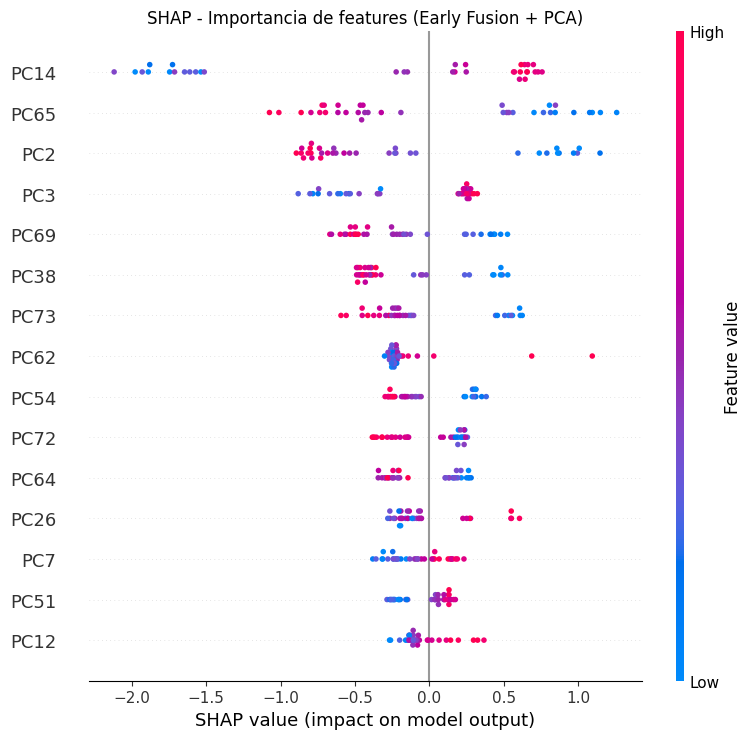

In [134]:
# ==========================================================
# SHAP - Interpretabilidad del mejor modelo Early Fusion
# ==========================================================

import shap
import matplotlib.pyplot as plt

# Asegurar que mejor_modelo es XGBoost (de resultados_pca)
explainer = shap.TreeExplainer(mejor_modelo)
shap_values = explainer.shap_values(X_dev_pca)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_dev_pca, feature_names=[f"PC{i}" for i in range(X_dev_pca.shape[1])],
                  max_display=15, show=False)
plt.title("SHAP - Importancia de features (Early Fusion + PCA)")
plt.tight_layout()
plt.savefig(BASE_PROYECTO / "week5_shap_early_fusion.png", dpi=200, bbox_inches="tight")
plt.show()

5.14. CORREGIR LA TABLA FINAL (Error crítico)

In [135]:
# ==========================================================
# CORRECCIÓN DE LA TABLA FINAL (Semana 4)
# ==========================================================

# Valores REALES de la Semana 4 (Sección 13 del notebook anterior)
datos_reales = {
    "Audio (SVM Lineal)": {"Accuracy": 0.66, "Precision": 0.50, "Recall": 0.42, "F1": 0.45, "AUC": 0.54},
    "Texto (XGBoost)": {"Accuracy": 0.63, "Precision": 0.40, "Recall": 0.17, "F1": 0.24, "AUC": 0.42}
}

# Actualizar la tabla_final (índices 2 y 3 en tu dataframe actual)
tabla_final.loc[2, "Accuracy"] = 0.66
tabla_final.loc[2, "Precision"] = 0.50
tabla_final.loc[2, "Recall"] = 0.42
tabla_final.loc[2, "F1"] = 0.45
tabla_final.loc[2, "AUC"] = 0.54

tabla_final.loc[3, "Accuracy"] = 0.63
tabla_final.loc[3, "Precision"] = 0.40
tabla_final.loc[3, "Recall"] = 0.17
tabla_final.loc[3, "F1"] = 0.24
tabla_final.loc[3, "AUC"] = 0.42

# Guardar la tabla corregida
tabla_final.to_csv(BASE_PROYECTO / "tabla_final_resultados_proyecto_delphin_CORREGIDA.csv", index=False)
display(tabla_final)

,Semana,Modalidad,Modelo,Accuracy,Precision,Recall,F1,AUC,Observación
0,2,Audio,MLP,0.600,0.400,0.330,0.364,0.402,Mejor modelo desarrollado en la Semana 2
1,3,Texto,MLP (BERT),0.514,0.222,0.167,0.190,0.471,Mejor modelo desarrollado en la Semana 3
2,4,Audio,SVM Lineal,0.660,0.500,0.420,0.450,0.540,Mejor clasificador clásico para audio
3,4,Texto,XGBoost (BERT),0.630,0.400,0.170,0.240,0.420,Mejor clasificador clásico para texto
4,5,Late Fusion,MLP Audio + MLP Texto,0.600,0.400,0.330,0.364,0.402,Mejor estrategia multimodal del proyecto
5,5,Late Fusion,SVM Audio + XGBoost Texto,0.630,0.400,0.170,0.240,0.402,"Mayor accuracy, menor sensibilidad para detect..."
6,5,Early Fusion,XGBoost + PCA (74 componentes),0.543,0.300,0.250,0.470,0.543,Reducción de 954 a 74 componentes mediante PCA
